In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [2]:
file = "time_series_60min_singleindex.csv"
df = pd.read_csv(file, index_col=0, parse_dates=True)
de_cols = [c for c in df.columns if c.startswith("DE_") and "load" in c.lower()]
print("Candidate DE load columns:", de_cols)

LOAD_COL = "DE_load_actual_entsoe_transparency"
load = df[LOAD_COL]

# Filter date range and checking for missing values
load = load.loc["2015-01-01":"2020-10-31"]
print("Missing values:", load.isna().sum(), "out of", len(load))
load = load.interpolate(limit_direction="both")
daily = load.resample("D").mean()
weekly = load.resample("W").mean()
df.head()

Candidate DE load columns: ['DE_load_actual_entsoe_transparency', 'DE_load_forecast_entsoe_transparency', 'DE_50hertz_load_actual_entsoe_transparency', 'DE_50hertz_load_forecast_entsoe_transparency', 'DE_LU_load_actual_entsoe_transparency', 'DE_LU_load_forecast_entsoe_transparency', 'DE_amprion_load_actual_entsoe_transparency', 'DE_amprion_load_forecast_entsoe_transparency', 'DE_tennet_load_actual_entsoe_transparency', 'DE_tennet_load_forecast_entsoe_transparency', 'DE_transnetbw_load_actual_entsoe_transparency', 'DE_transnetbw_load_forecast_entsoe_transparency']
Missing values: 0 out of 50400


,cet_cest_timestamp,AT_load_actual_entsoe_transparency,AT_load_forecast_entsoe_transparency,AT_price_day_ahead,AT_solar_generation_actual,AT_wind_onshore_generation_actual,BE_load_actual_entsoe_transparency,BE_load_forecast_entsoe_transparency,BE_solar_generation_actual,BE_wind_generation_actual,...,SI_load_actual_entsoe_transparency,SI_load_forecast_entsoe_transparency,SI_solar_generation_actual,SI_wind_onshore_generation_actual,SK_load_actual_entsoe_transparency,SK_load_forecast_entsoe_transparency,SK_solar_generation_actual,SK_wind_onshore_generation_actual,UA_load_actual_entsoe_transparency,UA_load_forecast_entsoe_transparency
utc_timestamp,,,,,,,,,,,,,,,,,,,,,
2014-12-31 23:00:00+00:00,2015-01-01T00:00:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-01 00:00:00+00:00,2015-01-01T01:00:00+0100,5946.0,6701.0,35.0,NaN,69.0,9484.0,9897.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-01 01:00:00+00:00,2015-01-01T02:00:00+0100,5726.0,6593.0,45.0,NaN,64.0,9152.0,9521.0,NaN,734.81,...,1045.47,816.0,NaN,1.17,2728.0,2860.0,3.8,NaN,NaN,NaN
2015-01-01 02:00:00+00:00,2015-01-01T03:00:00+0100,5347.0,6482.0,41.0,NaN,65.0,8799.0,9135.0,NaN,766.64,...,1004.79,805.0,NaN,1.04,2626.0,2810.0,3.8,NaN,NaN,NaN
2015-01-01 03:00:00+00:00,2015-01-01T04:00:00+0100,5249.0,6454.0,38.0,NaN,64.0,8567.0,8909.0,NaN,733.13,...,983.79,803.0,NaN,1.61,2618.0,2780.0,3.8,NaN,NaN,NaN


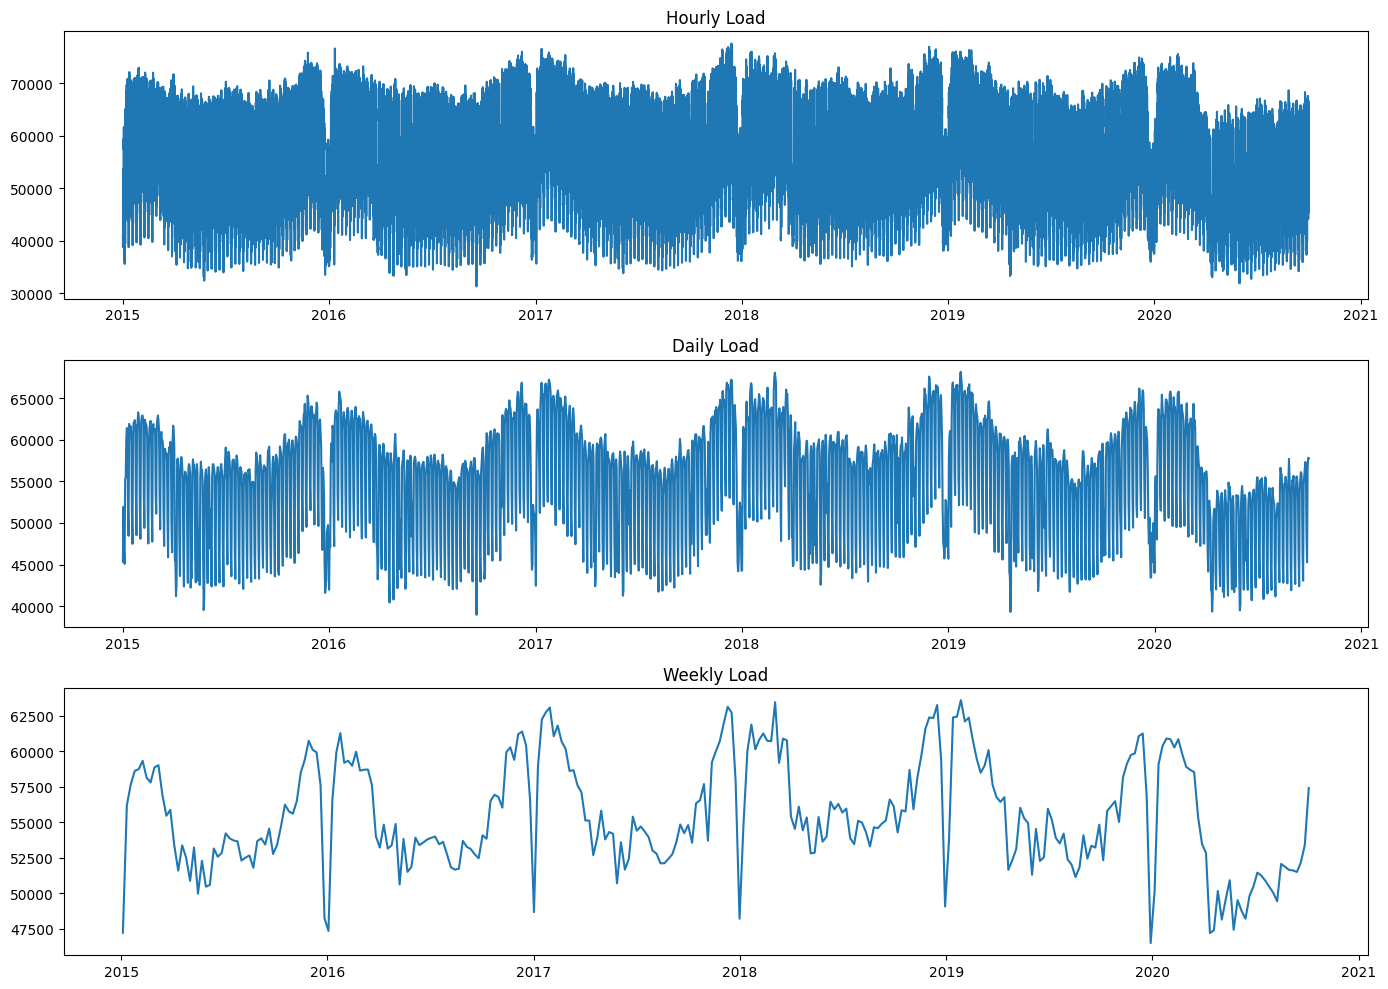

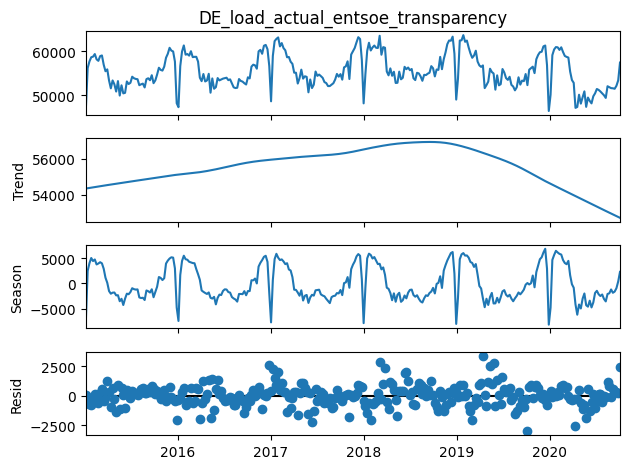

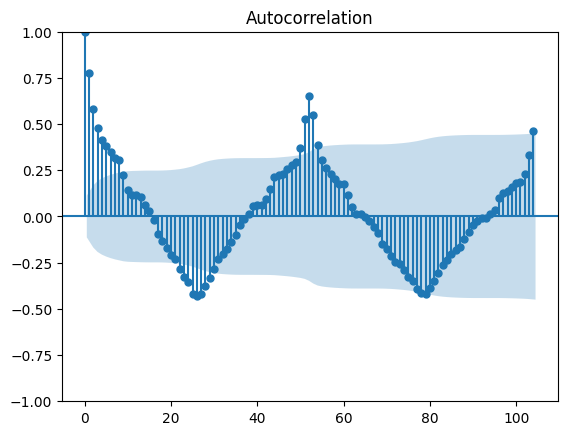

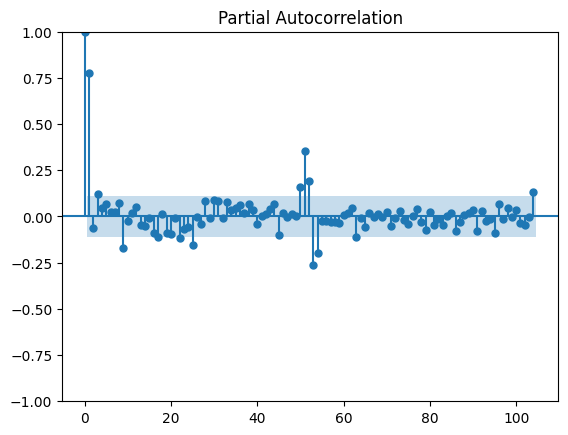

In [3]:
# Initial plots
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)
axes[0].plot(load)
axes[0].set_title("Hourly Load")
axes[1].plot(daily)
axes[1].set_title("Daily Load")
axes[2].plot(weekly)
axes[2].set_title("Weekly Load")
plt.tight_layout()
plt.show()

# Seasonal decomposition (weekly series, period=52 for annual seasonality)
stl = STL(weekly, period=52)
decomposition = stl.fit()
decomposition.plot()
plt.show()

# ACF / PACF
plot_acf(weekly.dropna(), lags=104)
plt.show()

plot_pacf(weekly.dropna(), lags=104)
plt.show()

In [4]:
# Stationarity testing (ADF)
def run_adf(series, label):
    result = adfuller(series.dropna())
    print(f"[{label}] ADF stat: {result[0]:.3f}, p-value: {result[1]:.4f}")
    return result[1]

p_raw = run_adf(weekly, "raw weekly")
p_diff1 = run_adf(weekly.diff(), "1st order diff")
p_sdiff = run_adf(weekly.diff(52), "seasonal diff (52)")

[raw weekly] ADF stat: -4.047, p-value: 0.0012
[1st order diff] ADF stat: -7.069, p-value: 0.0000
[seasonal diff (52)] ADF stat: -4.295, p-value: 0.0005


In [5]:
# 2-year forecasting horizon in weeks
HORIZON = 104

train = weekly.iloc[:-HORIZON]
test = weekly.iloc[-HORIZON:]

def mean_forecast(train, horizon, index):
    return pd.Series(train.mean(), index=index)

def naive_forecast(train, horizon, index):
    return pd.Series(train.iloc[-1], index=index)

def seasonal_naive_forecast(train, horizon, index, season_length=52):
    last_season = train.iloc[-season_length:]
    reps = int(np.ceil(horizon / season_length))
    values = np.tile(last_season.values, reps)[:horizon]
    return pd.Series(values, index=index)

def drift_forecast(train, horizon, index):
    n = len(train)
    slope = (train.iloc[-1] - train.iloc[0]) / (n - 1)
    values = [train.iloc[-1] + slope * (h + 1) for h in range(horizon)]
    return pd.Series(values, index=index)

def rmse(actual, predicted):
    return np.sqrt(np.mean((actual - predicted) ** 2))

mean_fc = mean_forecast(train, HORIZON, test.index)
naive_fc = naive_forecast(train, HORIZON, test.index)
seasonal_naive_fc = seasonal_naive_forecast(train, HORIZON, test.index)
drift_fc = drift_forecast(train, HORIZON, test.index)

results = {
    "Mean": rmse(test, mean_fc),
    "Naive": rmse(test, naive_fc),
    "Seasonal Naive": rmse(test, seasonal_naive_fc),
    "Drift": rmse(test, drift_fc),
}
print(results)

{'Mean': np.float64(4397.29969422285), 'Naive': np.float64(4459.108546494938), 'Seasonal Naive': np.float64(3006.7608119599954), 'Drift': np.float64(5117.957264105131)}


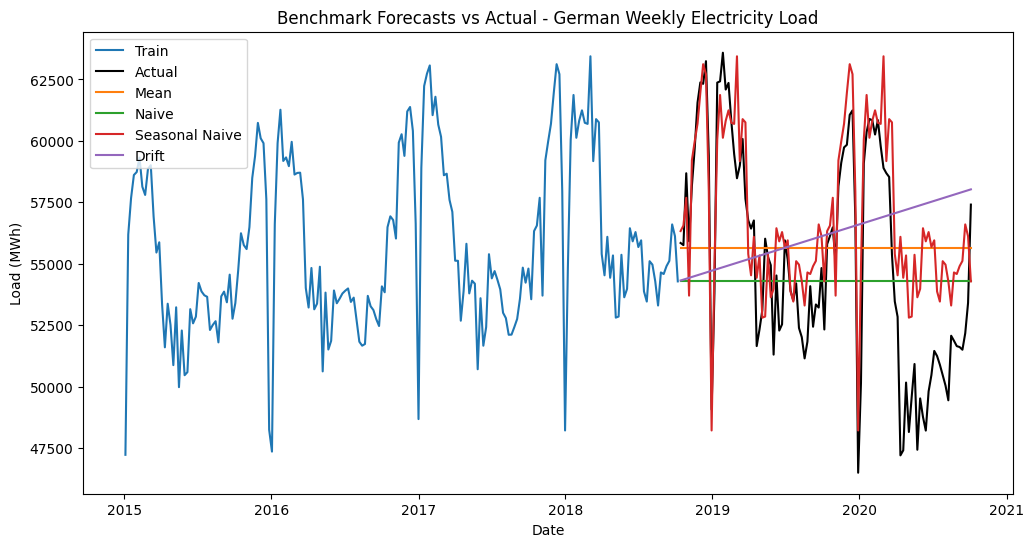

In [6]:
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual", color="black")
plt.plot(test.index, mean_fc, label="Mean")
plt.plot(test.index, naive_fc, label="Naive")
plt.plot(test.index, seasonal_naive_fc, label="Seasonal Naive")
plt.plot(test.index, drift_fc, label="Drift")
plt.legend()
plt.title("Benchmark Forecasts vs Actual - German Weekly Electricity Load")
plt.xlabel("Date")
plt.ylabel("Load (MWh)")
plt.show()

Seasonal Autoregressive Integrated Moving Average

In [7]:
HORIZON = 104
seasonal_order = (1, 1, 1, 52)
best_aic = None
best_order = None
all_results = []

for p in range(0, 7):      # 0,1,2,3,4,5,6
    for d in range(0, 3):  # 0,1,2
        for q in range(0, 7):  # 0,1,2,3,4,5,6
            order = (p, d, q)
            try:
                model = SARIMAX(train,
                    order=order,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False,)
                fit = model.fit(disp=False)
                aic = fit.aic
                all_results.append((p, d, q, aic))
                print(order, "AIC:", aic)

                if best_aic is None or aic < best_aic:
                    best_aic = aic
                    best_order = order
            except Exception as e:
                print(order, "failed:", e)
                continue

print("\nBest order found:", best_order, "with AIC:", best_aic)

results_df = pd.DataFrame(all_results, columns=["p", "d", "q", "aic"])
results_df = results_df.sort_values("aic")
final_model = SARIMAX(train ,order=best_order,seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
final_fit = final_model.fit(disp=False)
print(final_fit.summary())
residuals = final_fit.resid

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


(0, 0, 0) AIC: 1635.3429870141863


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


(0, 0, 1) AIC: 1603.930037282084


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


...

(6, 2, 5) AIC: 1515.4818334827708


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(6, 2, 6) AIC: 1487.9355365790639

Best order found: (2, 2, 6) with AIC: 1482.2660444232056


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                       SARIMAX Results                                        
Dep. Variable:     DE_load_actual_entsoe_transparency   No. Observations:                  197
Model:               SARIMAX(2, 2, 6)x(1, 1, [1], 52)   Log Likelihood                -730.133
Date:                                Wed, 15 Jul 2026   AIC                           1482.266
Time:                                        10:35:30   BIC                           1509.005
Sample:                                    01-04-2015   HQIC                          1493.015
                                         - 10-07-2018                                         
Covariance Type:                                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8927      0.292     -3.052      0.002      -1.466      -0.319
ar.

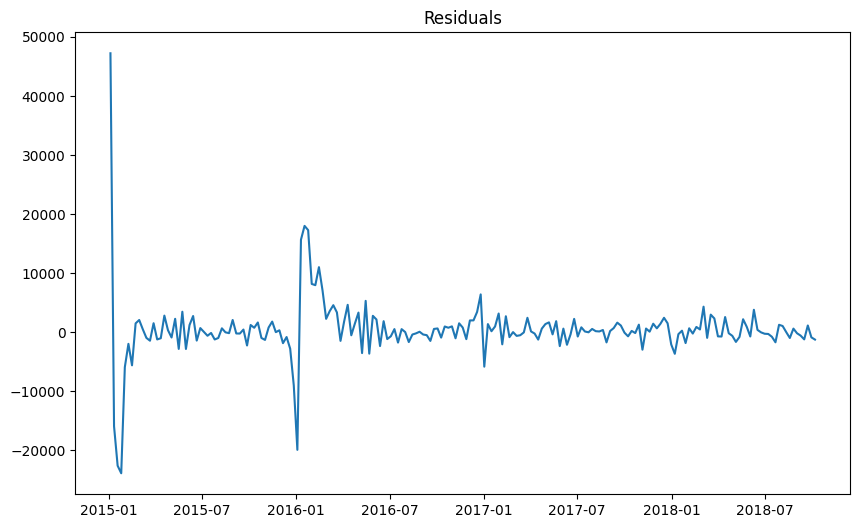

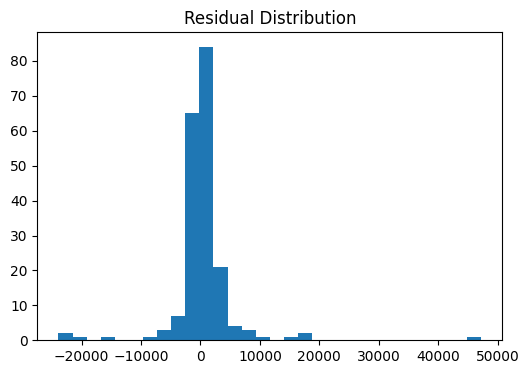

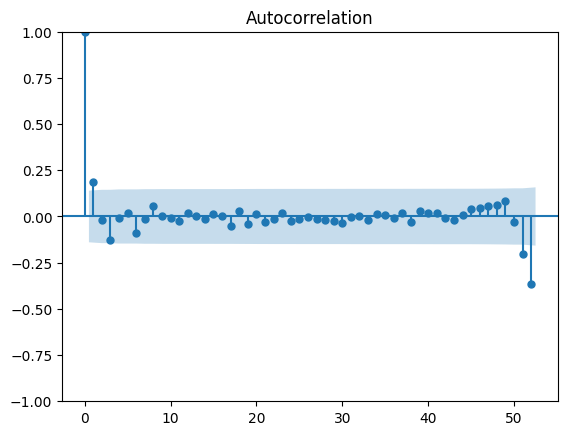

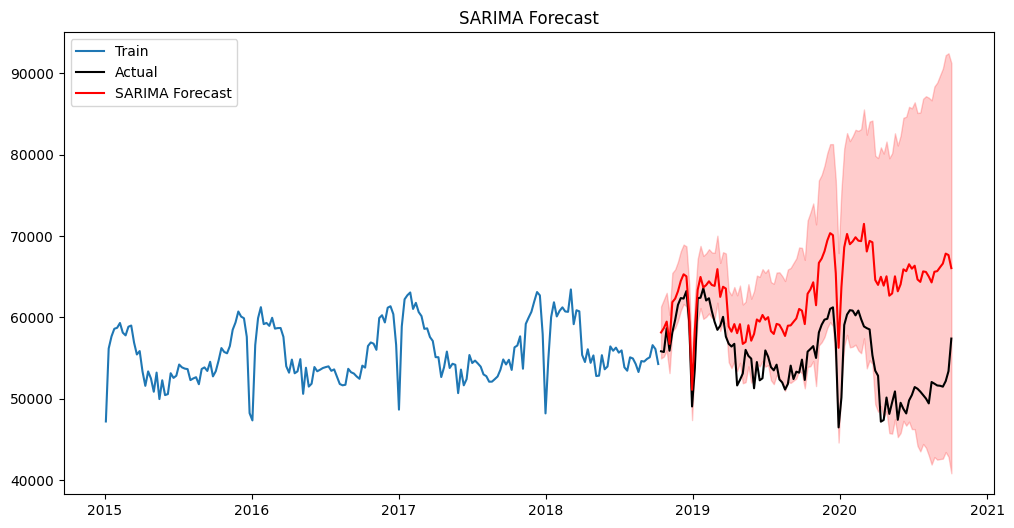

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(residuals)
plt.title("Residuals")
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=30)
plt.title("Residual Distribution")
plt.show()

plot_acf(residuals.dropna(), lags=52)
plt.show()

forecast = final_fit.get_forecast(steps=HORIZON)
forecast_values = forecast.predicted_mean
conf_int = forecast.conf_int()

plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual", color="black")
plt.plot(test.index, forecast_values, label="SARIMA Forecast", color="red")
plt.fill_between(test.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color="red", alpha=0.2)
plt.legend()
plt.title("SARIMA Forecast")
plt.show()


In [9]:
def rmse(actual, predicted):
    errors = actual.values - predicted.values
    return np.sqrt(np.mean(errors ** 2))
print("SARIMA RMSE:", rmse(test, forecast_values))

SARIMA RMSE: 9454.985188075942


Seasonal Autoregressive Integrated Moving Average with Exogenous Regressors

In [10]:
import requests
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 52.52,
    "longitude": 13.405,
    "start_date": "2015-01-01",
    "end_date": "2020-10-31",
    "daily": "temperature_2m_mean",
    "timezone": "Europe/Berlin",
}
response = requests.get(url, params=params)
data = response.json()

temp_daily = pd.Series(
    data["daily"]["temperature_2m_mean"],
    index=pd.to_datetime(data["daily"]["time"]),
)

temp_daily.index = temp_daily.index.tz_localize('Europe/Berlin', ambiguous='NaT', nonexistent='NaT').tz_convert('UTC')

temp_weekly = temp_daily.resample("W").mean()
temp_weekly = temp_weekly.reindex(weekly.index).interpolate(limit_direction='both')

temp_train = temp_weekly[:-HORIZON]
temp_test = temp_weekly[-HORIZON:]

model = SARIMAX(train, exog=temp_train, order=best_order, seasonal_order=seasonal_order,
                 enforce_stationarity=False, enforce_invertibility=False)
fit = model.fit(disp=False)
print(fit.summary())

forecast = fit.get_forecast(steps=HORIZON, exog=temp_test)
forecast_values = forecast.predicted_mean
conf_int = forecast.conf_int()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                       SARIMAX Results                                        
Dep. Variable:     DE_load_actual_entsoe_transparency   No. Observations:                  197
Model:               SARIMAX(2, 2, 6)x(1, 1, [1], 52)   Log Likelihood                -727.824
Date:                                Wed, 15 Jul 2026   AIC                           1479.648
Time:                                        10:36:10   BIC                           1508.818
Sample:                                    01-04-2015   HQIC                          1491.374
                                         - 10-07-2018                                         
Covariance Type:                                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
0           -119.5219     62.328     -1.918      0.055    -241.683       2.639
ar.

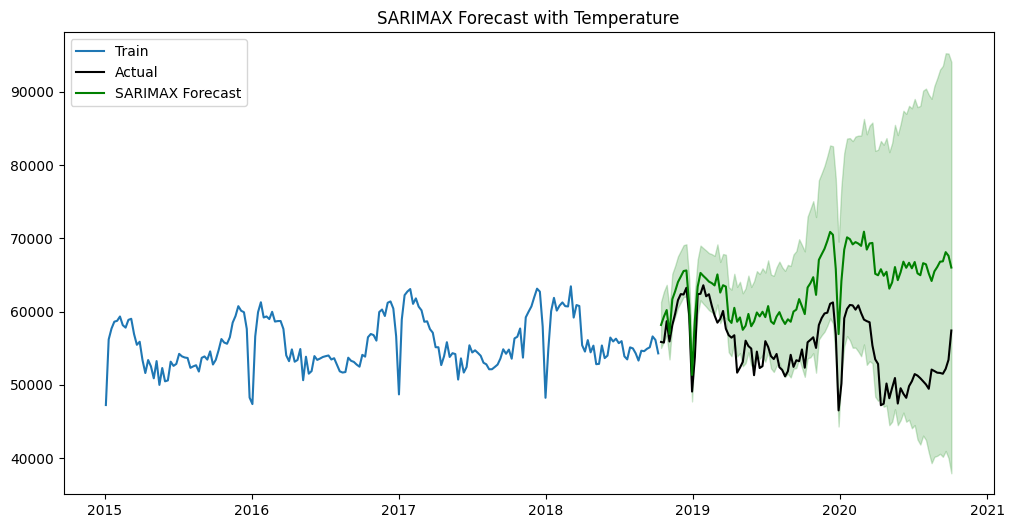

In [11]:

plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual", color="black")
plt.plot(test.index, forecast_values, label="SARIMAX Forecast", color="green")
plt.fill_between(test.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color="green", alpha=0.2)
plt.legend()
plt.title("SARIMAX Forecast with Temperature")
plt.show()

In [12]:
def rmse(actual, predicted):
    errors = actual.values - predicted.values
    return np.sqrt(np.mean(errors ** 2))

print("SARIMAX RMSE:", rmse(test, forecast_values))

SARIMAX RMSE: 9771.54009154891


Random forest:

In [13]:
features = pd.DataFrame(index=weekly.index)
features["load"] = weekly
features["temperature"] = temp_weekly

# Simple lag features (previous weeks' load)
features["load_lag_1"] = weekly.shift(1)
features["load_lag_2"] = weekly.shift(2)
features["load_lag_52"] = weekly.shift(52)  # same week last year
features["month"] = features.index.month
features["week_of_year"] = features.index.isocalendar().week.astype(int)

# Drop rows with missing values created by the lags
features = features.dropna()
train_features = features.loc[features.index.isin(train.index)]
test_features = features.loc[features.index.isin(test.index)]

X_train = train_features.drop(columns=["load"])
y_train = train_features["load"]
X_test = test_features.drop(columns=["load"])
y_test = test_features["load"]

# Trying a few simple settings manually instead of a big automated search
model = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42)
model.fit(X_train, y_train)
predictions = model.predict(X_test)
predictions = pd.Series(predictions, index=X_test.index)

In [14]:
def rmse(actual, predicted):
    errors = actual.values - predicted.values
    return np.sqrt(np.mean(errors ** 2))

print("Random Forest RMSE:", rmse(y_test, predictions))

Random Forest RMSE: 2541.47813381801


load_lag_52     0.783784
load_lag_1      0.076736
week_of_year    0.063405
temperature     0.048613
load_lag_2      0.021798
month           0.005663
dtype: float64


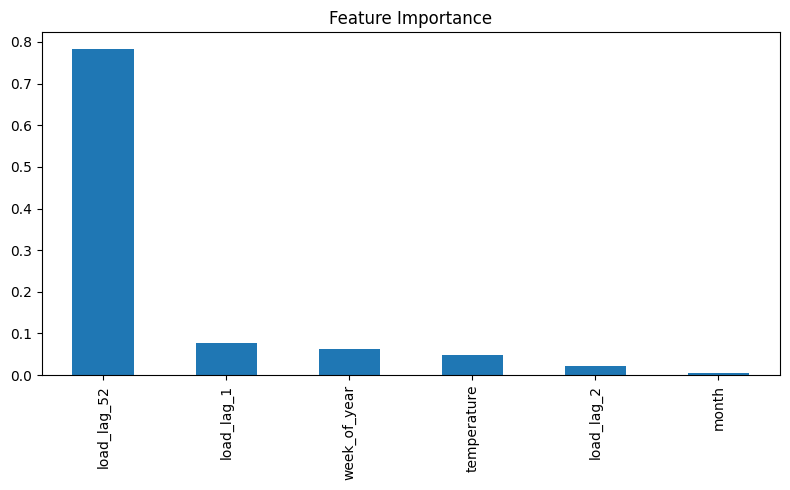

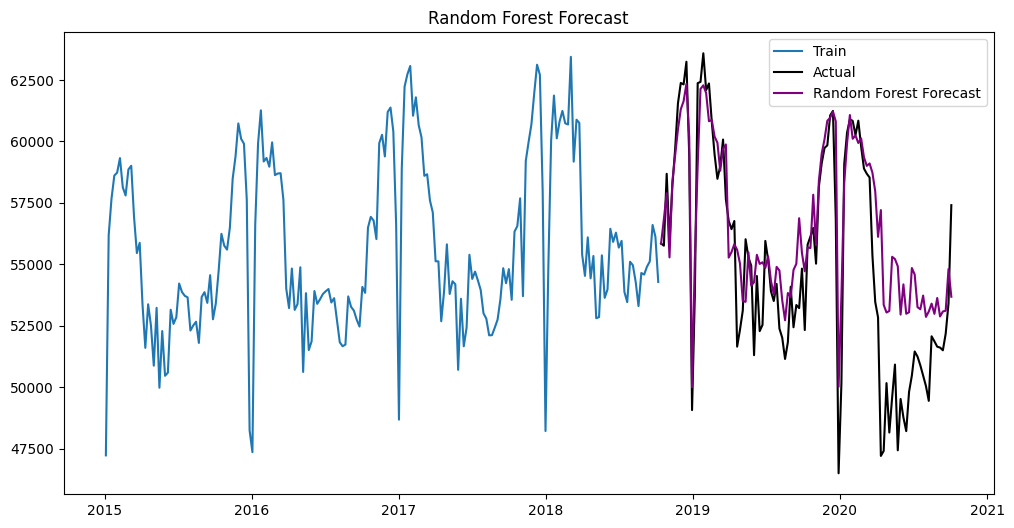

In [15]:
# Feature important
importance = pd.Series(model.feature_importances_, index=X_train.columns)
importance = importance.sort_values(ascending=False)
print(importance)

plt.figure(figsize=(8, 5))
importance.plot(kind="bar")
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

# Ploting forecast
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label="Train")
plt.plot(y_test.index, y_test, label="Actual", color="black")
plt.plot(predictions.index, predictions, label="Random Forest Forecast", color="purple")
plt.legend()
plt.title("Random Forest Forecast")
plt.show()

Long Short Term Memory

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
460/460 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 0.0151 - val_loss: 0.0019
Epoch 2/10
460/460 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0018 - val_loss: 0.0013
Epoch 3/10
460/460 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0013 - val_loss: 7.9511e-04
Epoch 4/10
460/460 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0010 - val_loss: 5.6471e-04
Epoch 5/10
460/460 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 8.7398e-04 - val_loss: 4.6193e-04
Epoch 6/10
460/460 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 7.3807e-04 - val_loss: 5.0072e-04
Epoch 7/10
460/460 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5.9758e-04 - val_loss: 2.9759e-04
Epoch 8/10
460/460 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5.7729e-04 - val_loss: 4.1768e-04
Epoch 9/10
460/460 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5.1754e-04 - val_loss: 4.2943e-04
Epoch 10/10
460/460 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 4.8322e-04 - val_loss: 3.6177e-04


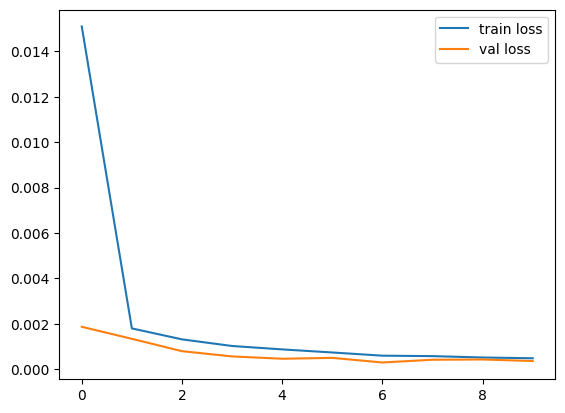

In [16]:
horizon_hours = 2 * 365 * 24  # 2 years of hourly data

train_hourly = load[:-horizon_hours]
test_hourly = load[-horizon_hours:]
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_hourly.values.reshape(-1, 1))
test_scaled = scaler.transform(test_hourly.values.reshape(-1, 1))

window = 168 # one week of hours

def make_sequences(data, window):
    X = []
    y = []
    for i in range(window, len(data)):
        X.append(data[i - window:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)
X_train, y_train = make_sequences(train_scaled, window)

# combining end of train with test so the first test predictions have history
combined = np.concatenate([train_scaled[-window:], test_scaled])
X_test, y_test = make_sequences(combined, window)

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# LSTM

model = Sequential()
model.add(LSTM(50, input_shape=(window, 1)))
model.add(Dense(1))

model.compile(optimizer="adam", loss="mse")

history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.1)

plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.legend()
plt.show()

548/548 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
LSTM RMSE: 1019.2391120897033
LSTM MAE: 754.0222349680722


Text(0.5, 1.0, 'LSTM Forecast (Hourly)')

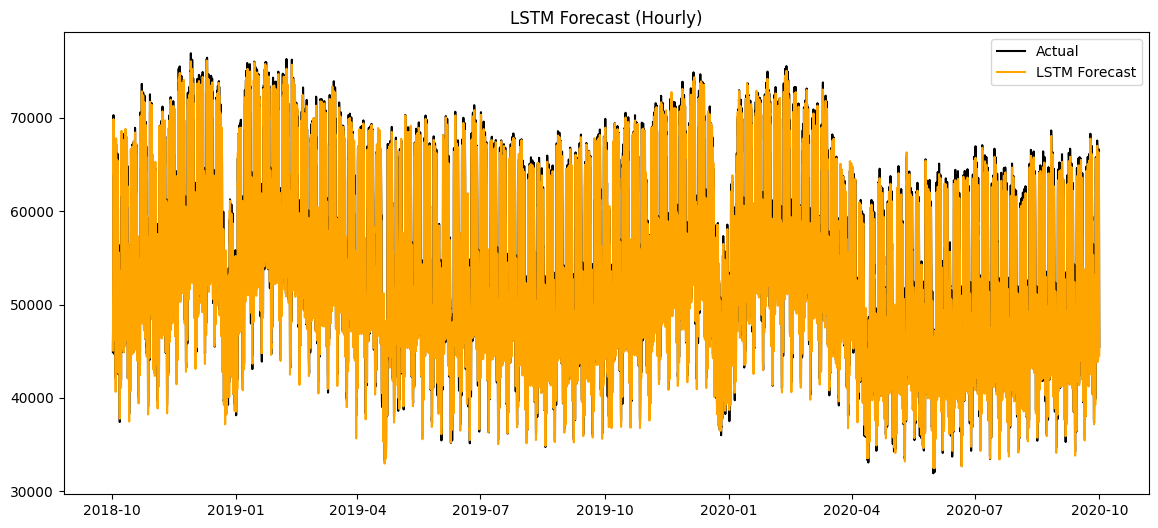

In [17]:
# Predicting and undo scaling
predictions_scaled = model.predict(X_test)
predictions = scaler.inverse_transform(predictions_scaled).flatten()
actual = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
rmse = np.sqrt(np.mean((actual - predictions) ** 2))
mae = np.mean(np.abs(actual - predictions))
print("LSTM RMSE:", rmse)
print("LSTM MAE:", mae)

plt.figure(figsize=(14, 6))
plt.plot(test_hourly.index, actual, label="Actual", color="black")
plt.plot(test_hourly.index, predictions, label="LSTM Forecast", color="orange")
plt.legend()
plt.title("LSTM Forecast (Hourly)")


## Model Comparison

,RMSE
LSTM,1019.239112
Seasonal Naive,3006.760812
Mean,4397.299694
Naive,4459.108546
Drift,5117.957264
SARIMA,9454.985188
SARIMAX,9771.540092
Random Forest,55640.586850


/tmp/ipykernel_239/1262265110.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rmse_series.index, y=rmse_series.values, palette="viridis")


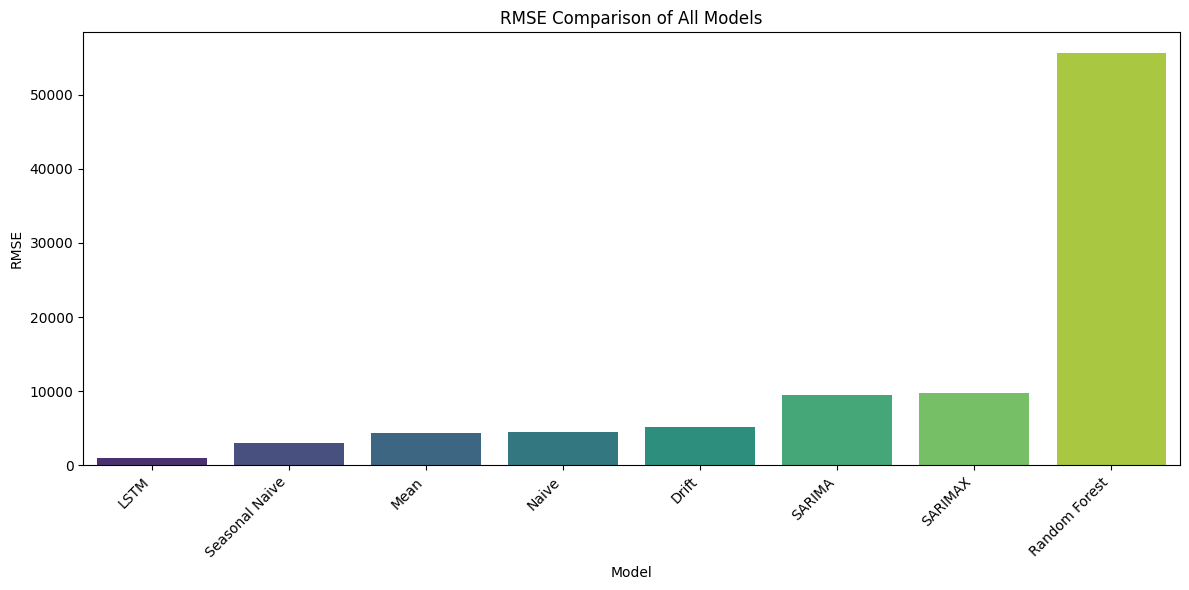

In [23]:
def rmse(actual, predicted):
    actual_array = actual.values if isinstance(actual, (pd.Series, pd.DataFrame)) else actual
    predicted_array = predicted.values if isinstance(predicted, (pd.Series, pd.DataFrame)) else predicted

    errors = actual_array - predicted_array
    return np.sqrt(np.mean(errors ** 2))

# Notting That SARIMA forecast_values and lstm and RMSE variable are overwritten in subsequent cells.
sarima_rmse_val = 9454.985188075942
sarimax_rmse_val = 9771.54009154891

lstm_rmse_val = 1019.2391120897033

model_rmse = {
    "Mean": results["Mean"],
    "Naive": results["Naive"],
    "Seasonal Naive": results["Seasonal Naive"],
    "Drift": results["Drift"],
    "SARIMA": sarima_rmse_val,
    "SARIMAX": sarimax_rmse_val,
    "Random Forest": rmse(y_test, predictions),
    "LSTM": lstm_rmse_val
}

rmse_series = pd.Series(model_rmse).sort_values()
display(rmse_series.to_frame(name="RMSE"))

plt.figure(figsize=(12, 6))
sns.barplot(x=rmse_series.index, y=rmse_series.values, palette="viridis")
plt.title("RMSE Comparison of All Models")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()